imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib as ta


Load Data

In [3]:
try:
    df = pd.read_csv('D:/kifiya AI/financial-news-sentiment/data/AAPL.csv')
except FileNotFoundError:
    import yfinance as yf
    df = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

Prepare Data

In [5]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

df.columns = [c.capitalize() for c in df.columns]

print(df.head())

               Close      High       Low      Open      Volume
Date                                                          
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


### Apply Analysis Indicators (TA-Lib)

Moving Averages (SMA/EMA)

In [6]:
# (SMA) - 20 day
df['SMA_20'] = ta.SMA(df['Close'], timeperiod=20)

# Exponential Moving Average (EMA) - 20 day
df['EMA_20'] = ta.EMA(df['Close'], timeperiod=20)

Relative Strength Index (RSI)

In [7]:
# RSI - Standard 14 day period
df['RSI'] = ta.RSI(df['Close'], timeperiod=14)

MACD (Moving Average Convergence Divergence)

In [8]:
# MACD returns three arrays: macd, macdsignal, macdhist
macd, macdsignal, macdhist = ta.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

df['MACD'] = macd
df['MACD_Signal'] = macdsignal

Financial Metrics (PyNance/Pandas)

In [9]:
# 1. Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

# 2. Cumulative Returns
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()

# 3. Volatility (Rolling Standard Deviation)
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

Visualization

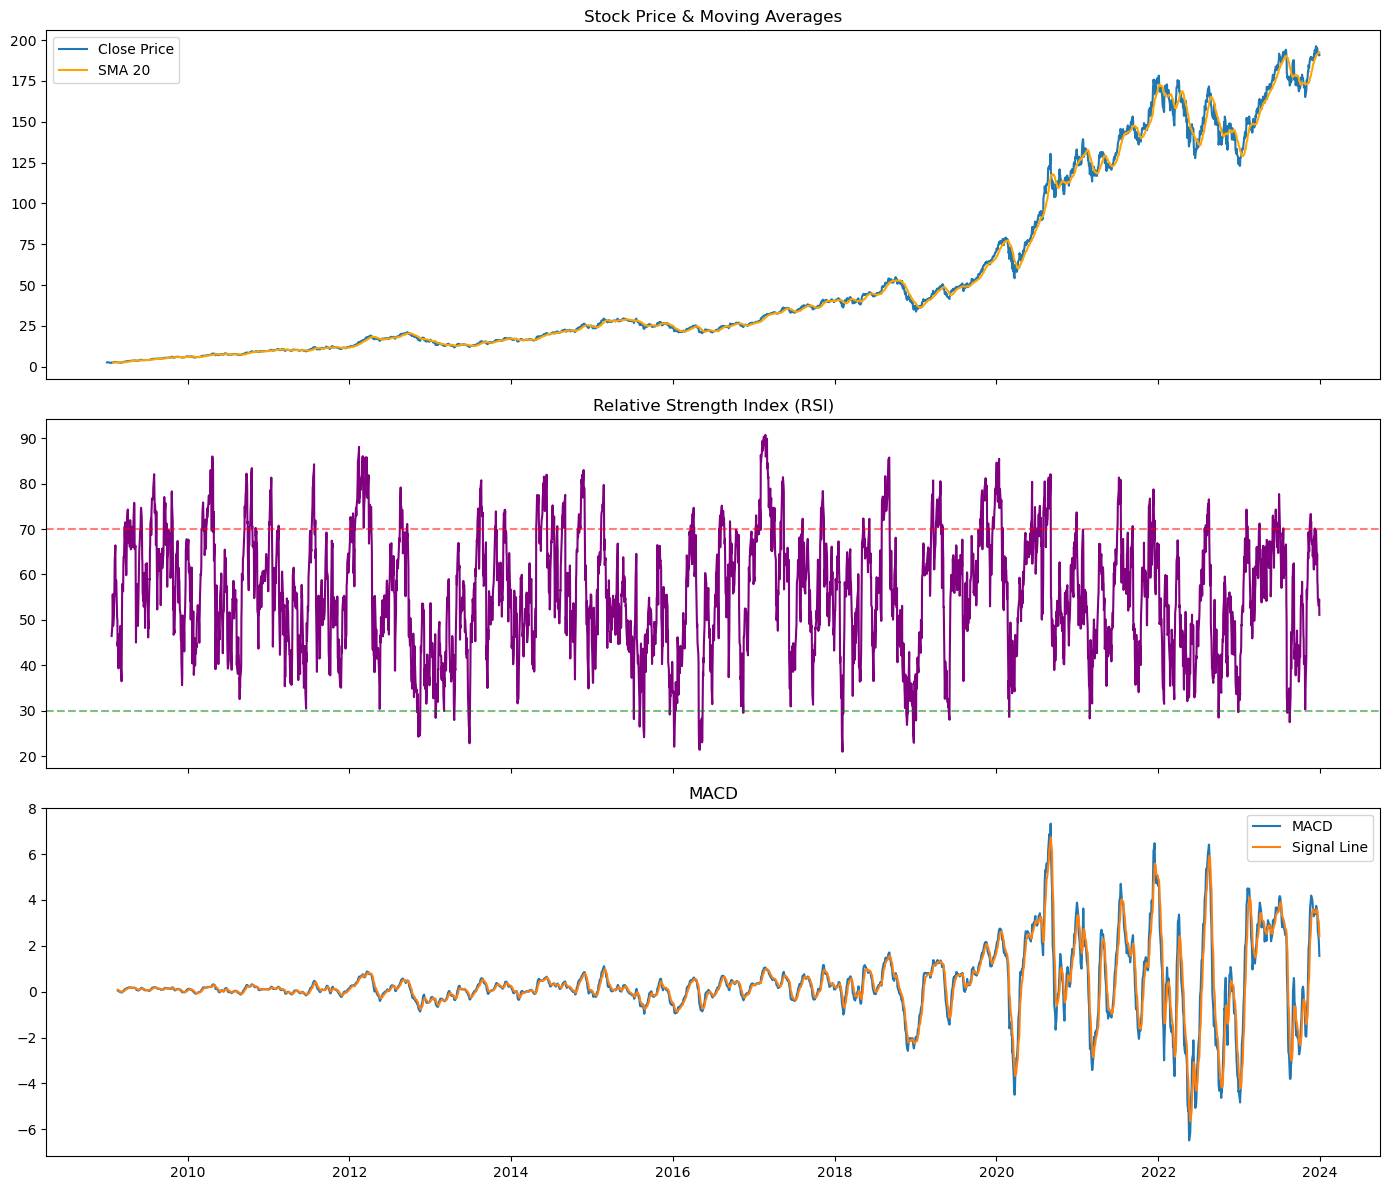

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot 1: Price and Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price')
ax1.plot(df.index, df['SMA_20'], label='SMA 20', color='orange')
ax1.set_title('Stock Price & Moving Averages')
ax1.legend()

# Plot 2: RSI
ax2.plot(df.index, df['RSI'], color='purple')
ax2.axhline(70, linestyle='--', alpha=0.5, color='red') # Overbought
ax2.axhline(30, linestyle='--', alpha=0.5, color='green') # Oversold
ax2.set_title('Relative Strength Index (RSI)')

# Plot 3: MACD
ax3.plot(df.index, df['MACD'], label='MACD')
ax3.plot(df.index, df['MACD_Signal'], label='Signal Line')
ax3.set_title('MACD')
ax3.legend()

plt.tight_layout()
plt.show()